## __State Reducers__
### Objective
Dive into reducers, which specify how state updates are performed on specific keys / channels in the state schema.

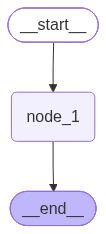

In [1]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
graph.invoke({"foo" : 18})

---Node 1---


{'foo': 19}

By default LangGraph doesn't know the preferred way to update the state.

So, it will just overwrite the value of foo in `node_1`:

    return {"foo": state['foo'] + 1}
If we pass `{'foo': 18}` as input, the state returned from the graph is `{'foo': 19}`

### Branching

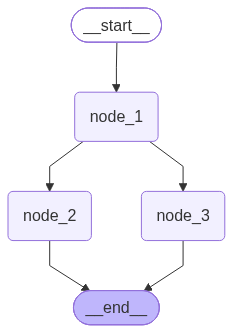

In [3]:
class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}
def node_2(state):
    print("---Node 2---")
    return {"foo": state['foo'] + 1}
def node_3(state):
    print("---Node 3---")
    return {"foo": state['foo'] + 1}

builder= StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"foo" : 9})
except InvalidUpdateError as e:
    print("Caught InvalidUpdateError:", e)



---Node 1---
---Node 2---
---Node 3---
Caught InvalidUpdateError: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


We see a problem!

Node 1 branches to nodes 2 and 3.

Nodes 2 and 3 run in `parallel`, which means they run in the same step of the graph.

They both attempt to `overwrite` the state _within the same step_.

This is ambiguous for the graph! Which state should it keep?

### __Reducers__
Reducers give us a general way to address this problem.

They specify how to perform updates.

We can use the `Annotated` type to specify a reducer function.

For example, in this case let's append the value returned from each node rather than overwriting them.

We just need a reducer that can perform this: __`operator.add`__ is a function from Python's built-in operator module.

When operator.add is applied to lists, it performs list concatenation.

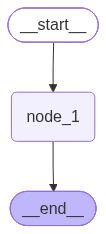

In [6]:
from operator import add
from typing import Annotated

class State(TypedDict):
    foo: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][0] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"foo" : [10]})

---Node 1---


{'foo': [10, 11]}

Now, our state key `foo` is a list.

This `operator.add` reducer function will append updates from each node to this list.

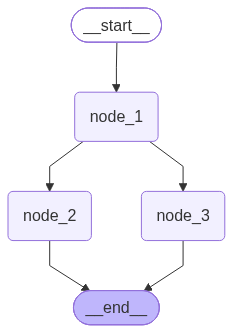

In [9]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][-1] + 1]}

def node_2(state):
    print("---Node 2---")
    return {"foo": [state['foo'][-1] + 1]}

def node_3(state):
    print("---Node 3---")
    return {"foo": [state['foo'][-1] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:

graph.invoke({"foo" : [1]})

---Node 1---
---Node 2---
---Node 3---


{'foo': [1, 2, 3, 3]}

In [16]:
try:
    graph.invoke({"foo" : None})
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


### Custom Reducers

To address cases like this,we can also define custom reducers.

For example, lets define custom reducer logic to combine lists and handle cases where either or both of the inputs might be `None`.

In [17]:
def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

In `node_1`, we append the value `2`.

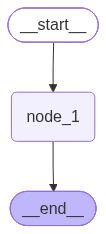

TypeError occurred: can only concatenate list (not "NoneType") to list


In [22]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [2]}

# Build graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

Now, try with our `custom reducer`. We can see that no error is thrown.

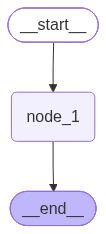

---Node 1---


In [23]:
builder= StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    graph.invoke({"foo" : None})
except TypeError as e:
    print(f"TypeError occurred: {e}")

### Messages
Use a built-in reducer, `add_messages`, to handle messages in state.

We also showed that `MessagesState` is a useful shortcut if you want to work with messages.

* `MessagesState` has a built-in messages key
* It also has a built-in `add_messages` reducer for this key

These two are equivalent.

We'll use the `MessagesState` class via from `langgraph.graph import MessagesState` for brevity.

In [25]:
from typing import Annotated
from langgraph.graph import MessagesState
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# Define a custom TypedDict that includes a list of messages with add_messages reducer
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str

# Use MessagesState, which includes the messages key with add_messages reducer
class ExtendedMessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    added_key_1: str
    added_key_2: str

usage of the `add_messages` reducer.

In [27]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

initial_message=[AIMessage(content="Hello, how can I assist you today?", name="Model"),
                 HumanMessage(content="I need help with LangGraph messages.", name="Abdullah")]

new_message=[AIMessage(content="Sure, I can help you with that. What specific questions do you have?", name="Model")]

add_messages(initial_message, new_message)


[AIMessage(content='Hello, how can I assist you today?', additional_kwargs={}, response_metadata={}, name='Model', id='5c9f90d0-e33e-4ca4-aad6-fa4a66e7b272', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I need help with LangGraph messages.', additional_kwargs={}, response_metadata={}, name='Abdullah', id='dd30918c-ec62-499b-a85f-ceedd38c387c'),
 AIMessage(content='Sure, I can help you with that. What specific questions do you have?', additional_kwargs={}, response_metadata={}, name='Model', id='7150231e-b391-493a-97af-9ddd2bf55c4f', tool_calls=[], invalid_tool_calls=[])]

So we can see that `add_messages` allows us to append messages to the `messages` key in our state.

### Re-writing

If we pass a message with the same ID as an existing one in our messages list, it will get overwritten!

In [29]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model", id="1"),
                    HumanMessage(content="I'm looking for information on RAG.", name="Abdullah", id="2")
                   ]

# New message to add
new_message = HumanMessage(content="I'm looking for information on Agentic RAG", name="Abdullah", id="2")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on Agentic RAG", additional_kwargs={}, response_metadata={}, name='Abdullah', id='2')]

### Removal
We can remove messages by using `RemoveMessage`.

In [37]:
from langchain_core.messages import RemoveMessage

# Message list
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Abdullah", id="2"))
messages.append(AIMessage("So you said you were researching Agentic AI?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about Agentic AI. But what other mechanisms are there?", name="Abdullah", id="4"))

# Isolate messages to delete
delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]
print(delete_messages)

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]


In [39]:
delete_messages

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]

In [43]:
messages

[AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Abdullah', id='2'),
 AIMessage(content='So you said you were researching Agentic AI?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about Agentic AI. But what other mechanisms are there?', additional_kwargs={}, response_metadata={}, name='Abdullah', id='4')]

__NOTE__:-\
`RemoveMessage` does not modify your __local Python list directly__(i.e. `messages` array). It is a special instruction modifier used to tell a `LangGraph state compiler` to __remove those messages from its persistent storage during a graph update__.

In [40]:
add_messages(messages , delete_messages)

[AIMessage(content='So you said you were researching Agentic AI?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about Agentic AI. But what other mechanisms are there?', additional_kwargs={}, response_metadata={}, name='Abdullah', id='4')]

We can see that mesage IDs 1 and 2, as noted in `delete_messages` are removed by the reducer.